In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

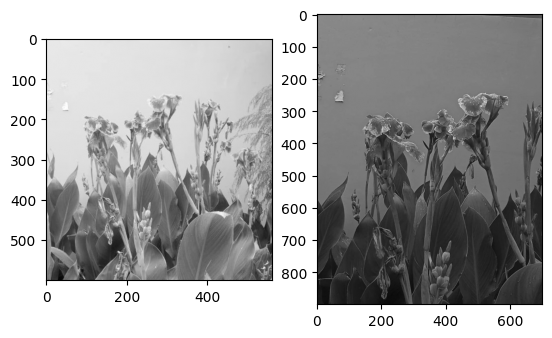

In [2]:
img1 = cv2.imread("flower a1 copy.jpeg", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("flower a2.jpeg", cv2.IMREAD_GRAYSCALE)

img2 = cv2.resize(img2, (700, 900))

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap = 'gray')
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap = 'gray')

In [3]:
orb = cv2.ORB_create(nfeatures = 1000)

In [4]:
kp1, des1 = orb.detectAndCompute(img1, None)
kp2, des2 = orb.detectAndCompute(img2, None)

In [5]:
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck = True)

In [6]:
matches = bf.match(des1, des2)

In [7]:
matches = sorted(matches, key = lambda x : x.distance)

In [8]:
result_img = cv2.drawMatches(
    img1, kp1,
    img2, kp2,
    matches[:30], None,
    flags = cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

In [9]:
cv2.imshow("ORB Feature Matches", result_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

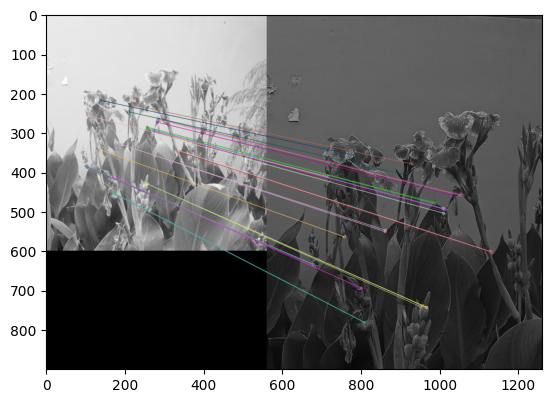

In [10]:
plt.imshow(result_img)

In [24]:
import cv2
import numpy as np

# Step 1: Load the query template image (e.g., book cover)
query_img = cv2.imread("linked profile.jpg", cv2.IMREAD_GRAYSCALE)
if query_img is None:
    print("Error: Could not load template.jpg!")
    exit()

# Initialize ORB detector and compute template keypoints
orb = cv2.ORB_create(nfeatures=1000)
kp_query, des_query = orb.detectAndCompute(query_img, None)

# Get dimensions of template image
h_q, w_q = query_img.shape
query_pts = np.float32([[0, 0], [0, h_q], [w_q, h_q], [w_q, 0]]).reshape(-1, 1, 2)

# Initialize Matcher
bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)

# Start Webcam
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    # Detect keypoints and descriptors in live webcam frame
    kp_frame, des_frame = orb.detectAndCompute(frame_gray, None)

    if des_frame is not None and len(des_frame) > 10:
        # Match descriptors between template and webcam frame
        matches = bf.match(des_query, des_frame)
        matches = sorted(matches, key=lambda x: x.distance)

        # Select good matches (top 15% or at least 15 points)
        good_matches = matches[:min(30, len(matches))]

        if len(good_matches) >= 10:
            # Extract coordinates of matched keypoints in both images
            src_pts = np.float32([kp_query[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
            dst_pts = np.float32([kp_frame[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)

            # Compute Homography matrix using RANSAC to reject outliers
            M, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

            if M is not None:
                # Perspective transform the query corners to find target corners in the live frame
                dst_corners = cv2.perspectiveTransform(query_pts, M)

                # Draw green bounding box around detected target object
                frame = cv2.polylines(frame, [np.int32(dst_corners)], True, (0, 255, 0), 3)
                cv2.putText(frame, "Object Detected!", (20, 40), 
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    cv2.imshow("Real-Time Feature Tracking & Homography", frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

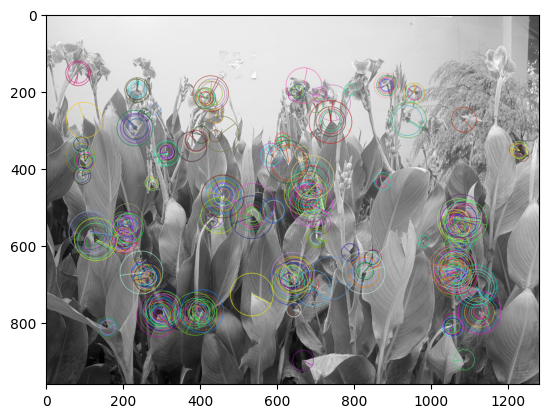

In [26]:
flower = cv2.imread("flower a3.jpeg", cv2.IMREAD_GRAYSCALE)

orb = cv2.ORB_create()
keypoints = orb.detect(flower, None)
keypoints,_ = orb.compute(flower, keypoints)
flower = cv2.drawKeypoints(flower, keypoints, flower, flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
plt.imshow(flower)

In [32]:
import cv2

# Load image
img = cv2.imread('shapes.png')

# Store levels in a list
gaussian_pyramid = [img]

# Generate 3 downsampled levels (Total 4 levels including base)
current_level = img
for i in range(3):
    current_level = cv2.pyrDown(current_level)
    gaussian_pyramid.append(current_level)

# Display dimensions at each level
for level_idx, level_img in enumerate(gaussian_pyramid):
    print(f"Level {level_idx} Shape: {level_img.shape}")
    cv2.imshow(f"Gaussian Pyramid Level {level_idx}", level_img)

cv2.waitKey(0)
cv2.destroyAllWindows()

Level 0 Shape: (1536, 2816, 3)
Level 1 Shape: (768, 1408, 3)
Level 2 Shape: (384, 704, 3)
Level 3 Shape: (192, 352, 3)


In [30]:
import cv2
import numpy as np

# Step 1: Load image
img = cv2.imread('shapes.png')
img = cv2.resize(img, (512, 512))  # Resize to power of 2 for clean division

# Step 2: Build Gaussian Pyramid
G = img.copy()
gaussian_pyramid = [G]
for i in range(3):
    G = cv2.pyrDown(G)
    gaussian_pyramid.append(G)

# Step 3: Build Laplacian Pyramid
laplacian_pyramid = []
for i in range(3, 0, -1):
    # Upsample higher Gaussian level to match lower level dimensions
    GE = cv2.pyrUp(gaussian_pyramid[i])
    
    # Subtract to isolate bandpass edge features
    L = cv2.subtract(gaussian_pyramid[i - 1], GE)
    laplacian_pyramid.append(L)

# Display isolated Laplacian edge details
for idx, lap in enumerate(laplacian_pyramid):
    cv2.imshow(f"Laplacian Level {idx + 1} (Detail Map)", lap)

cv2.waitKey(0)
cv2.destroyAllWindows()